### 1. Inisialisasi Environment, Google Drive, dan Fungsi Utilitas Kinerja
Sel ini berfungsi untuk memuat pustaka dasar (seperti `pandas`, `numpy`, dan `psutil`), memeriksa versi pustaka, memasang Google Drive untuk penyimpanan, serta menyiapkan fungsi pembantu untuk mengukur penggunaan memori (RSS) dan waktu eksekusi (`ukur`), serta pencatatan silsilah data (`lineage`).

In [ ]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Mounted at /content/drive


### 2. Pengunduhan Data Mentah secara Aman dan Pemuatan Dataset Trip Taxi
Sel ini mendefinisikan fungsi `unduh_aman` dengan mekanisme *retry* dan *exponential backoff* untuk mengunduh dataset Yellow Taxi (Parquet) dan Zona taksi (CSV) dari server Cloudfront, lalu memuat data perjalanan taksi ke dalam DataFrame.

In [ ]:
import requests, shutil

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)  # atomik
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)  # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA, compression='gzip')

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

[unduh trip] 0.33 s
[unduh zona] 0.04 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.0 MB
[baca trip] 1.31 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


### 3. Integrasi Data Cuaca Sekunder melalui API Open-Meteo
Sel ini mengambil data historis cuaca (suhu dan curah hujan) per jam di New York selama bulan Januari 2023 menggunakan API gratis Open-Meteo dengan penanganan kegagalan koneksi.

In [ ]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                               "temperature_2m": "suhu_c",
                               "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.65 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


### 4. Setup Database Operasional SQLite dan Simulasi Data
Sel ini membuat database SQLite operasional lokal untuk menyimpan tabel referensi tarif pembayaran dan mensimulasikan pemuatan data transaksi secara bertahap (*chunk-by-chunk*) untuk menghemat memori.

In [ ]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                         "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                           engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


### 5. Profiling Kualitas Data dan Laporan Aturan Validasi
Sel ini melakukan analisis awal kualitas data (profiling dimensi) dan menguji kebersihan data berdasarkan 8 aturan kualitas data (seperti validitas durasi, jarak perjalanan, dan jangkauan tanggal) untuk memetakan persentase kegagalan data.

In [ ]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


### 6. Imputasi Data Hilang dan Pembersihan Duplikat
Sel ini membandingkan beberapa strategi imputasi untuk data jumlah penumpang yang hilang (`passenger_count`) menggunakan median/modus per jam, serta mendeteksi dan menghapus entri duplikat pada kunci transaksi utama.

In [ ]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


### 7. Penanganan Outlier dan Penggabungan Data (*Data Join*)
Sel ini mendeteksi pencilan (*outliers*) menggunakan metode IQR, melakukan *winsorizing* pada jarak perjalanan, dan menggabungkan data perjalanan utama dengan tabel dimensi zona taksi, referensi pembayaran, serta data cuaca eksternal.

In [ ]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa

n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                       on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


### 8. Rekayasa Fitur dan Pembagian Data untuk Machine Learning
Sel ini membuat fitur baru seperti `akhir_pekan`, kecepatan rata-rata, dan status hujan. Data kemudian dibagi menjadi data latih dan uji, lalu dilakukan penskalaan nilai numerik (`StandardScaler`) serta pengodean kategori (`OneHotEncoder`).

In [ ]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])  # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


### 9. Visualisasi Distribusi Biaya Perjalanan Sebelum dan Sesudah Pembersihan
Sel ini menghasilkan plot perbandingan histogram untuk melihat perbedaan distribusi variabel target `total_amount` sebelum dilakukan pra-pemrosesan data dibandingkan dengan setelah dibersihkan dari pencilan.

Analisis Hasil — Grafik Pembanding Distribusi

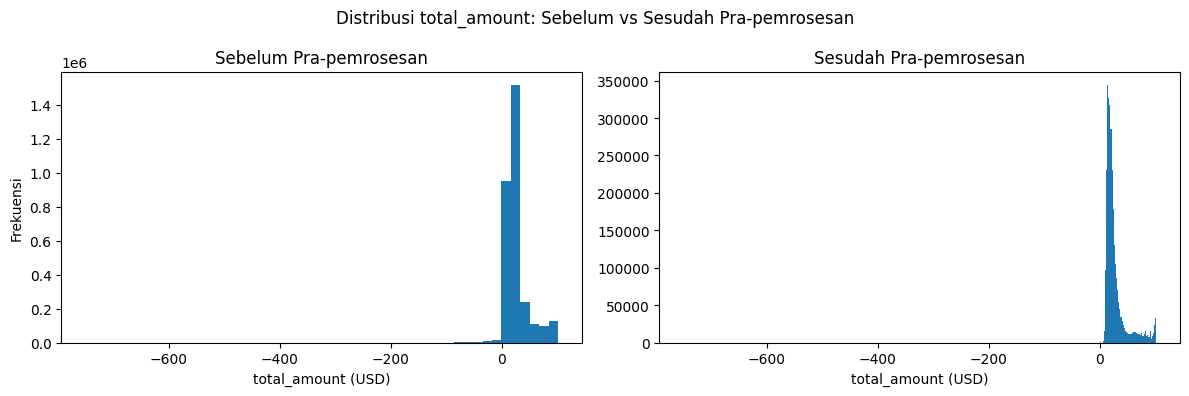

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
batas_atas_plot = trip["total_amount"].quantile(0.99)  # biar histogram tidak gepeng oleh outlier ekstrem

axes[0].hist(trip["total_amount"].clip(upper=batas_atas_plot), bins=50)
axes[0].set_title("Sebelum Pra-pemrosesan")
axes[0].set_xlabel("total_amount (USD)")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(bersih["total_amount"].clip(upper=batas_atas_plot), bins=50)
axes[1].set_title("Sesudah Pra-pemrosesan")
axes[1].set_xlabel("total_amount (USD)")

fig.suptitle("Distribusi total_amount: Sebelum vs Sesudah Pra-pemrosesan")
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_total_amount.png", dpi=150)
plt.show()

### 10. Studi Kasus: Analisis Agregasi Tarif dan Pengaruh Cuaca Hujan
Sel ini membuat tabel analitik teragregasi per wilayah asal (`borough_naik`) dan waktu per jam untuk melihat dampak cuaca hujan terhadap rata-rata tarif perjalanan taksi per mil.

Studi Kasus

In [ ]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

print(tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median().unstack())

tabel_analitik.to_parquet(f"{DIR_SIMPAN}/tabel_analitik.parquet", index=False)

hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


### 11. Pipeline Pembersihan Terintegrasi dan Bukti Idempotensi
Sel ini membungkus seluruh langkah pembersihan data ke dalam satu fungsi terintegrasi `pipeline` yang dilengkapi fungsi verifikasi kontrak data (`validasi`), mengekspor hasilnya ke format Parquet berpartisi, dan mengompresnya menjadi ZIP.

In [ ]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona, compression='gzip')

    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                           .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))

    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]

    df = (df.merge(z[["LocationID", "Borough"]]
                    .rename(columns={"Borough": "borough_naik"}),
                    left_on="PULocationID", right_on="LocationID",
                    how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))

    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")

    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 9.31 s
[tulis parquet berpartisi] 3.86 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

### 12. Latihan 2: Penambahan Aturan Validasi Jumlah Tip
Sel ini menyelesaikan latihan kedua dengan menambahkan aturan validasi baru untuk memeriksa kelayakan nilai tip (`tip_amount`) agar tidak bernilai negatif dan tidak melebihi total pembayaran keseluruhan.

Latihan 2

In [ ]:
aturan["validitas: tip_amount >= 0"] = trip["tip_amount"] >= 0
aturan["konsistensi: tip_amount <= total_amount"] = trip["tip_amount"] <= trip["total_amount"]

laporan_latihan2 = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan_latihan2

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
9,konsistensi: tip_amount <= total_amount,3041561,25204,0.822
6,konsistensi: total >= fare,3041743,25023,0.816
8,validitas: tip_amount >= 0,3066540,225,0.007
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


### 13. Latihan 3: Analisis Rute Perjalanan Terpopuler Antar Borough
Sel ini mengintegrasikan informasi wilayah tujuan (`borough_turun`) ke dalam data perjalanan bersih untuk menganalisis 10 pasangan rute perjalanan (asal ke tujuan) yang paling sering digunakan oleh penumpang.

Latihan 3

In [ ]:
bersih_tujuan = bersih.merge(
    zona[["LocationID", "Borough"]].rename(columns={"Borough": "borough_turun"}),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one"
).drop(columns="LocationID")

top10_pasangan = (bersih_tujuan
    .groupby(["borough_naik", "borough_turun"], observed=True)
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10))
top10_pasangan

,borough_naik,borough_turun,jumlah_perjalanan
22,Manhattan,Manhattan,2491566
29,Queens,Manhattan,155261
23,Manhattan,Queens,82354
20,Manhattan,Brooklyn,62986
30,Queens,Queens,59146
27,Queens,Brooklyn,42187
42,Unknown,Manhattan,18432
45,Unknown,Unknown,13562
19,Manhattan,Bronx,8865
8,Brooklyn,Brooklyn,7910


### 14. Latihan 4: Penskalaan Fitur Menggunakan MinMaxScaler
Sel ini melatih fitur numerik menggunakan `MinMaxScaler` untuk mentransformasikan data ke dalam rentang nilai terikat [0, 1] dan membandingkan rentang distribusinya dengan hasil `StandardScaler`.

Latihan 4

In [ ]:
from sklearn.preprocessing import MinMaxScaler

skala_minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_minmax = skala_minmax.transform(latih[FITUR_NUM])

print("StandardScaler - rentang latih:", latih_num.min(axis=0).round(3), "s/d", latih_num.max(axis=0).round(3))
print("MinMaxScaler   - rentang latih:", latih_minmax.min(axis=0).round(3), "s/d", latih_minmax.max(axis=0).round(3))

StandardScaler - rentang latih: [-0.794 -1.226 -2.288] s/d [ 4.247 13.925  3.347]
MinMaxScaler   - rentang latih: [0. 0. 0.] s/d [1. 1. 1.]


### 15. Latihan 5: Pengujian Validasi Integritas Relasi (*Many-to-One*)
Sel ini mendemonstrasikan pentingnya validasi integritas relasi tabel saat melakukan penggabungan data (*join*) dengan sengaja merusak keunikan kunci tabel dimensi dan menangkap error yang dihasilkan.

Latihan 5

In [ ]:
zona_rusak = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)  # duplikasi baris pertama
print("kunci zona (rusak) unik?", zona_rusak["LocationID"].is_unique)

try:
    _ = bersih.merge(
        zona_rusak[["LocationID", "Borough", "Zone"]],
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one")
    print("Join berhasil (tidak seharusnya!)")
except Exception as e:
    print(f"Error tertangkap seperti yang diharapkan: {type(e).__name__}: {e}")

print("kunci zona (asli) masih unik?", zona["LocationID"].is_unique)  # zona asli tidak tersentuh

kunci zona (rusak) unik? False
Error tertangkap seperti yang diharapkan: MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
kunci zona (asli) masih unik? True


### 16. Latihan 6: Implementasi Pipeline Data Inkremental
Sel ini mengimplementasikan fungsi `pipeline_inkremental` untuk memproses data bulanan baru secara aman. Fungsi ini mendeteksi jika data bulan terkait telah diproses sebelumnya untuk menghindari eksekusi ganda (idempoten).

Latihan 6

In [ ]:
def pipeline_inkremental(bulan, out_dir=OUT):
    """Hanya memproses bulan yang belum ada di direktori keluaran."""
    tanda = f"{out_dir}/_selesai_{bulan}.txt"
    if os.path.exists(tanda):
        print(f"{bulan}: sudah diproses sebelumnya, dilewati")
        return None
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path)
    hasil_bulan = pipeline(path, PATH_ZONA, cuaca, tarif_referensi)
    hasil_bulan["tanggal"] = hasil_bulan["tpep_pickup_datetime"].dt.date.astype(str)
    hasil_bulan.to_parquet(out_dir, partition_cols=["borough_naik"], index=False)
    with open(tanda, "w") as f:
        f.write(pd.Timestamp.now("UTC").isoformat())
    print(f"{bulan}: diproses, {len(hasil_bulan):,} baris ditulis")
    return hasil_bulan

pipeline_inkremental("2023-01")                       # panggilan 1: memproses
jumlah_sebelum = len(os.listdir(OUT))
pipeline_inkremental("2023-01")                       # panggilan 2: harus dilewati
jumlah_sesudah = len(os.listdir(OUT))
print("idempoten (tidak ada berkas baru)?", jumlah_sebelum == jumlah_sesudah)

cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
2023-01: diproses, 2,986,910 baris ditulis
2023-01: sudah diproses sebelumnya, dilewati
idempoten (tidak ada berkas baru)? True


### 17. Latihan 1: Peningkatan Fungsi Unduh dengan Laporan Kecepatan Transfer
Sel ini memperbarui fungsi unduh aman menjadi `unduh_aman_v2` yang mampu menghitung dan menampilkan kecepatan pengunduhan file data dalam satuan Megabyte per detik (MB/s).

Latihan 1

In [ ]:
def unduh_aman_v2(url, tujuan, percobaan=3, jeda_awal=2):
    """Versi Latihan 1: mencetak kecepatan unduh dalam MB/detik."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t0 = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            durasi = time.perf_counter() - t0
            ukuran_mb = os.path.getsize(sementara) / 1024**2
            print(f"kecepatan unduh: {ukuran_mb/durasi:.2f} MB/detik ({ukuran_mb:.2f} MB dalam {durasi:.2f}s)")
            os.replace(sementara, tujuan)
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

# Hapus dulu berkas trip yang ada supaya panggilan pertama benar-benar mengunduh (demo saja)
os.remove(PATH_TRIP)
unduh_aman_v2(URL_TRIP, PATH_TRIP)   # panggilan 1: mengunduh, kecepatan MB/s tercetak
unduh_aman_v2(URL_TRIP, PATH_TRIP)   # panggilan 2: harus pakai cache

kecepatan unduh: 118.26 MB/detik (45.46 MB dalam 0.38s)
cache ditemukan: yellow_tripdata_2023-01.parquet


'/content/lapisan_mentah/yellow_tripdata_2023-01.parquet'

### 18. Pemrosesan Data Skala Besar Menggunakan PySpark
Sel ini mendemonstrasikan bagaimana logika pembersihan data yang sebelumnya menggunakan Pandas dikonversi menggunakan PySpark SQL guna menangani dataset berukuran besar secara paralel dan efisien menggunakan teknik Broadcast Join.

In [ ]:
!pip install -q pyspark==3.5.1
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                      "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 1.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 15.24 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocation

### Lampiran A: Pemeriksaan Output Banding Strategi Imputasi
Sel ini digunakan untuk menampilkan kembali ringkasan statistik dari hasil uji coba berbagai strategi penanganan data hilang pada kolom jumlah penumpang.

In [ ]:
banding

,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


### Lampiran B: Pemeriksaan Output Ringkasan Deteksi Outlier
Sel ini menampilkan hasil deteksi pencilan (outliers) menggunakan metode statistik IQR dan Z-score untuk variabel jarak, durasi, dan total biaya sebelum dilakukan pembersihan.

In [ ]:
ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


### Lampiran C: Pemeriksaan Output Profiling Kolom Dataset
Sel ini menampilkan hasil profiling lengkap dari variabel-variabel dalam tabel perjalanan taksi mentah sebelum diproses.

In [ ]:
profil

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3
